# Classical Posterior Sampling

This demo compares three classical approaches for a Bayesian inverse problem: importance sampling, Markov chain Monte Carlo, and ensemble Kalman inversion. The common test problem keeps the notation fixed, so the differences between the methods are visible in the particles, chains, ensembles, and diagnostics.

See Chapter 1, Section 1.2.2: Posterior Expectations; Chapter 15, Section 15.3: Ensemble Kalman Inversion; and Chapter 15, Section 15.5: Markov Chain Monte Carlo.


## Bayesian inverse problem used throughout

The unknown parameter is $u = (u_1,u_2) \in \mathbb{R}^2$. We use a bimodal prior
$$
\rho(u) = \frac{1}{2}\mathcal{N}\left(u;(-2,-2),I\right)
       + \frac{1}{2}\mathcal{N}\left(u;(2,2),1.5I\right),
$$
and noisy observations
$$
y = H u + \eta, \qquad \eta \sim \mathcal{N}(0,\sigma_{\rm obs}^2 I).
$$
The observation operator $H$ may observe both coordinates, only $u_1$, or only $u_2$. The likelihood is denoted by
$$
\ell(y \mid u) \propto
\exp\left(-\frac{1}{2}\|y-Hu\|_{\Gamma}^{2}\right),
\qquad \Gamma = \sigma_{\rm obs}^2 I,
$$
and the posterior density is proportional to
$$
\pi^y(u) \propto \ell(y \mid u)\rho(u).
$$

Because this example is two-dimensional, the true prior, likelihood, and unnormalized posterior can be drawn on a grid. The same grid is only used for visualization; the sampling and ensemble methods use particles in parameter space.


## Importance sampling

Importance sampling estimates posterior expectations by drawing samples $u^{(j)}$ from a proposal density $q$ and assigning normalized weights
$$
W^{(j)} =
\frac{\ell(y\mid u^{(j)})\rho(u^{(j)})/q(u^{(j)})}
{\sum_{k=1}^N \ell(y\mid u^{(k)})\rho(u^{(k)})/q(u^{(k)})}.
$$
In this demo the proposal is the prior, $q=\rho$, so the unnormalized weights are just the likelihood values $\ell(y\mid u^{(j)})$. The effective sample size (ESS) measures weight concentration:
$$
\mathrm{ESS} = \frac{1}{\sum_{j=1}^N (W^{(j)})^2}.
$$
Large ESS means many particles contribute; small ESS means only a few particles carry most of the posterior mass. With the displayed defaults, the full observation $y=(0,0)$ and `noise_std = 1.0` produce a bimodal posterior with modes between the data and the two prior modes.

**Parameter exploration.**

- Adjust `n_samples`. More particles make the weighted empirical density less noisy, but this only helps substantially when enough prior particles land in regions of high likelihood.
- Adjust `noise_std`. Smaller observation noise makes the likelihood sharper and can drive weight collapse; larger observation noise keeps both prior modes visible for data placed between them.
- Adjust `observation`. Observing only one coordinate leaves the other coordinate less constrained, while observing both coordinates concentrates the posterior more strongly.
- Adjust `y1` and `y2`. Moving the data toward one prior mode makes that mode dominate; placing the data between modes can make the posterior bimodal and more sensitive to finite-sample variability.

**Recommended test combinations.** Keep the other parameters at their displayed defaults and compare the weighted particles, ESS, and weighted empirical KDE.

| Exp ID | Observation | Data | Noise | Samples |
| :--- | :--- | :--- | :---: | :---: |
| **1** | Full $(u_1,u_2)$ | $(0,0)$ | 1.0 | 300 |
| **2** | Full $(u_1,u_2)$ | $(0,0)$ | 0.5 | 300 |
| **3** | Full $(u_1,u_2)$ | $(0,0)$ | 0.2 | 300 |
| **4** | Full $(u_1,u_2)$ | $(2,2)$ | 1.0 | 300 |
| **5** | $u_1$ only | $0$ | 1.0 | 300 |
| **6** | Full $(u_1,u_2)$ | $(0,0)$ | 1.0 | 1000 |


Importance sampling: ESS = 66.1 out of N = 300 particles.


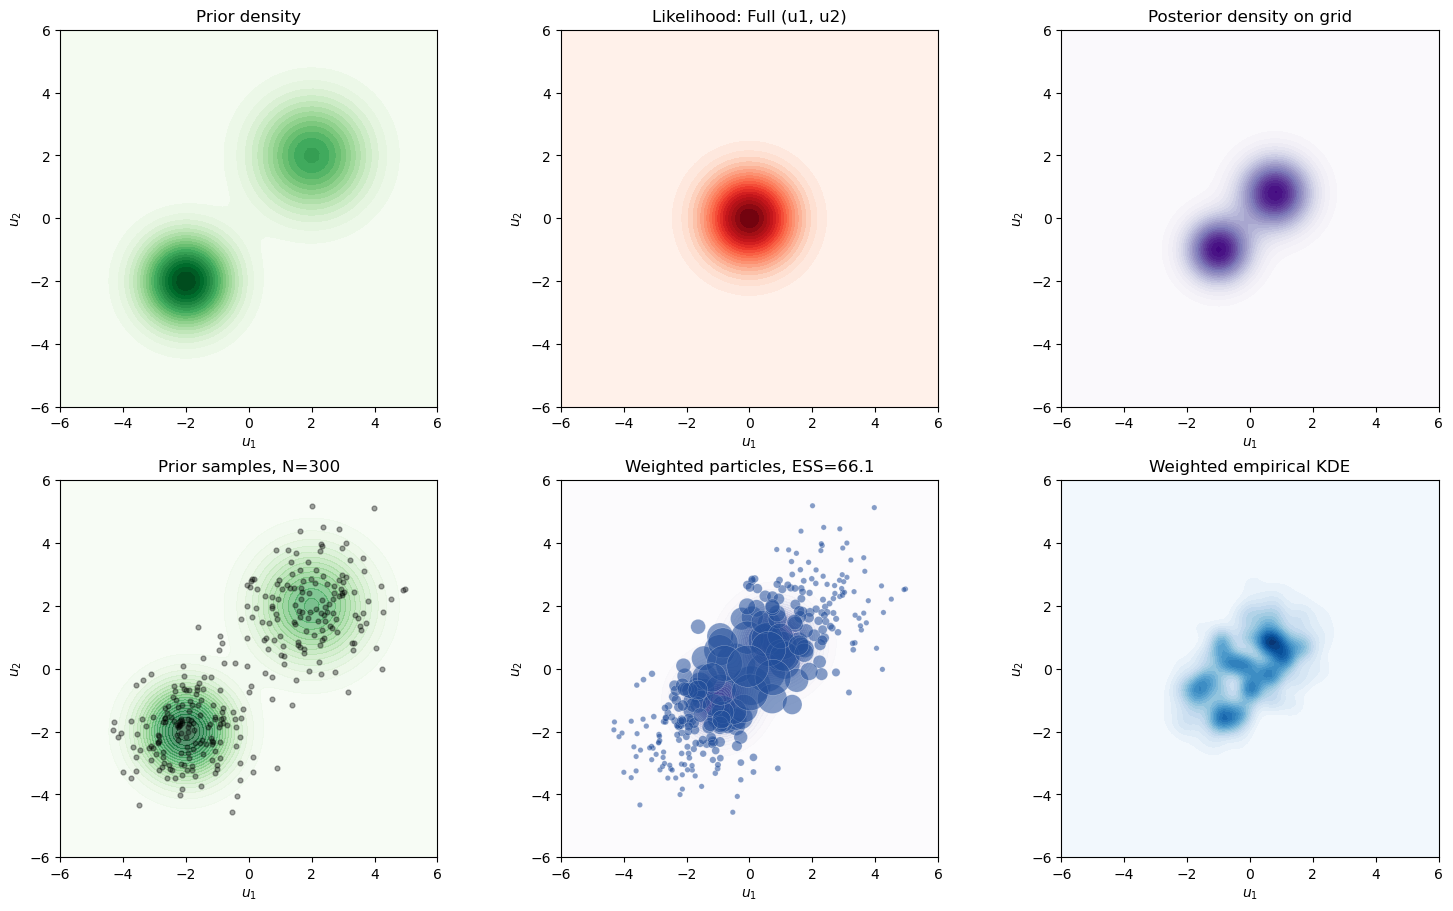

In [ ]:
#@title Importance sampling with the prior proposal
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import multivariate_normal, norm

DEFAULTS = {
    "n_samples": 300,
    "observation": "Full (u1, u2)",
    "y1": 0.0,
    "y2": 0.0,
    "noise_std": 1.0,
    "seed": 42,
    "grid_size": 80,
    "grid_limit": 6.0,
    "bandwidth": 0.28,
}

use_default = False #@param {type:"boolean"}
n_samples = 300 #@param {type:"slider", min:50, max:2000, step:50}
observation = "Full (u1, u2)" #@param ["Full (u1, u2)", "U1 only", "U2 only"]
y1 = 0.0 #@param {type:"slider", min:-4.0, max:4.0, step:0.25}
y2 = 0.0 #@param {type:"slider", min:-4.0, max:4.0, step:0.25}
noise_std = 1.0 #@param {type:"slider", min:0.1, max:2.0, step:0.1}

params = DEFAULTS.copy()
if not use_default:
    params.update({
        "n_samples": int(n_samples),
        "observation": observation,
        "y1": float(y1),
        "y2": float(y2),
        "noise_std": float(noise_std),
    })

def prior_pdf(pos):
    p1 = multivariate_normal.pdf(pos, mean=[-2, -2], cov=np.eye(2))
    p2 = multivariate_normal.pdf(pos, mean=[2, 2], cov=1.5 * np.eye(2))
    return 0.5 * p1 + 0.5 * p2

def sample_prior(n, rng):
    comp = rng.integers(0, 2, size=n)
    samples = np.zeros((n, 2))
    n0 = np.sum(comp == 0)
    n1 = n - n0
    samples[comp == 0] = rng.multivariate_normal([-2, -2], np.eye(2), size=n0)
    samples[comp == 1] = rng.multivariate_normal([2, 2], 1.5 * np.eye(2), size=n1)
    return samples

def observation_values(u, mode):
    if mode == "Full (u1, u2)":
        return u
    if mode == "U1 only":
        return u[..., 0:1]
    return u[..., 1:2]

def observed_data(p):
    if p["observation"] == "Full (u1, u2)":
        return np.array([p["y1"], p["y2"]])
    if p["observation"] == "U1 only":
        return np.array([p["y1"]])
    return np.array([p["y2"]])

def likelihood_pdf_on_grid(pos, y_obs, noise, mode):
    if mode == "Full (u1, u2)":
        return multivariate_normal.pdf(pos, mean=y_obs, cov=(noise ** 2) * np.eye(2))
    values = observation_values(pos, mode)[..., 0]
    return norm.pdf(values, loc=y_obs[0], scale=noise)

def likelihood_at_samples(samples, y_obs, noise, mode):
    hx = observation_values(samples, mode)
    residual = hx - y_obs
    exponent = -0.5 * np.sum((residual / noise) ** 2, axis=-1)
    return np.exp(exponent)

def weighted_kde(pos, samples, weights, bandwidth):
    density = np.zeros(pos.shape[:2])
    active = weights > 1e-5
    for sample, weight in zip(samples[active], weights[active]):
        density += weight * multivariate_normal.pdf(pos, mean=sample, cov=bandwidth ** 2)
    return density

rng = np.random.default_rng(params["seed"])
y_obs = observed_data(params)
grid = np.linspace(-params["grid_limit"], params["grid_limit"], params["grid_size"])
U1, U2 = np.meshgrid(grid, grid)
pos = np.dstack((U1, U2))

prior = prior_pdf(pos)
likelihood = likelihood_pdf_on_grid(pos, y_obs, params["noise_std"], params["observation"])
posterior = prior * likelihood
posterior = posterior / np.trapezoid(np.trapezoid(posterior, grid, axis=0), grid)

samples = sample_prior(params["n_samples"], rng)
unnormalized = likelihood_at_samples(samples, y_obs, params["noise_std"], params["observation"])
weights = unnormalized / np.sum(unnormalized)
ess = 1.0 / np.sum(weights ** 2)
kde = weighted_kde(pos, samples, weights, params["bandwidth"])

fig, axes = plt.subplots(2, 3, figsize=(15, 9), constrained_layout=True)

axes[0, 0].contourf(U1, U2, prior, levels=24, cmap="Greens")
axes[0, 0].set_title("Prior density")
axes[0, 1].contourf(U1, U2, likelihood, levels=24, cmap="Reds")
axes[0, 1].set_title(f"Likelihood: {params['observation']}")
axes[0, 2].contourf(U1, U2, posterior, levels=24, cmap="Purples")
axes[0, 2].set_title("Posterior density on grid")

axes[1, 0].contourf(U1, U2, prior, levels=24, cmap="Greens", alpha=0.65)
axes[1, 0].scatter(samples[:, 0], samples[:, 1], s=12, color="black", alpha=0.35)
axes[1, 0].set_title(f"Prior samples, N={params['n_samples']}")

size = 15 + 900 * weights / weights.max()
axes[1, 1].contourf(U1, U2, posterior, levels=24, cmap="Purples", alpha=0.55)
axes[1, 1].scatter(samples[:, 0], samples[:, 1], s=size, color="#234f9b", alpha=0.55, edgecolor="white", linewidth=0.25)
axes[1, 1].set_title(f"Weighted particles, ESS={ess:.1f}")

axes[1, 2].contourf(U1, U2, kde, levels=24, cmap="Blues")
axes[1, 2].set_title("Weighted empirical KDE")

for ax in axes.flat:
    ax.set_xlabel("$u_1$")
    ax.set_ylabel("$u_2$")
    ax.set_xlim(-params["grid_limit"], params["grid_limit"])
    ax.set_ylim(-params["grid_limit"], params["grid_limit"])
    ax.set_aspect("equal")

print(f"Importance sampling: ESS = {ess:.1f} out of N = {params['n_samples']} particles.")
plt.show()


## MCMC Sampler

Markov chain Monte Carlo replaces independent weighted particles with a Markov chain whose stationary distribution is the posterior. In the random walk Metropolis algorithm, the current state $u^{(n)}$ proposes
$$
v = u^{(n)} + \xi, \qquad \xi \sim \mathcal{N}(0,\sigma_{\rm prop}^2 I),
$$
and accepts the proposal with probability
$$
a(u^{(n)},v) = \min\left\{1,\frac{\pi^y(v)}{\pi^y(u^{(n)})}\right\}.
$$
The normalizing constant of the posterior cancels in this ratio. The proposal scale $\sigma_{\rm prop}$ controls the tradeoff between small accepted moves and large rejected moves. The burn-in fraction indicates the initial part of the chain discarded before estimating the posterior density. The default data and noise match the bimodal posterior from the first experiment.

**Parameter exploration.**

- Adjust `proposal_scale`. Small proposals are accepted often but move slowly; large proposals jump farther but are rejected more often and can leave repeated states in the trace.
- Adjust `n_steps`. Longer chains give more opportunities to move between high-probability regions, especially when the posterior has separated modes.
- Adjust `burn_in_fraction`. A larger burn-in removes more dependence on the starting point but leaves fewer samples for the empirical density.
- Adjust `noise_std`. Sharper likelihoods create narrower posterior regions, so proposal tuning becomes more important.

**Recommended test combinations.** Keep the other parameters at their displayed defaults and compare the chain path, trace plot, acceptance rate, and empirical KDE.

| Exp ID | Proposal scale | Steps | Burn-in | Noise |
| :--- | :---: | :---: | :---: | :---: |
| **1** | 0.15 | 2500 | 0.25 | 1.0 |
| **2** | 0.55 | 2500 | 0.25 | 1.0 |
| **3** | 1.50 | 2500 | 0.25 | 1.0 |
| **4** | 0.55 | 6000 | 0.25 | 1.0 |
| **5** | 0.35 | 6000 | 0.30 | 0.5 |


Random walk Metropolis: acceptance rate = 0.70, burn-in = 625 steps.


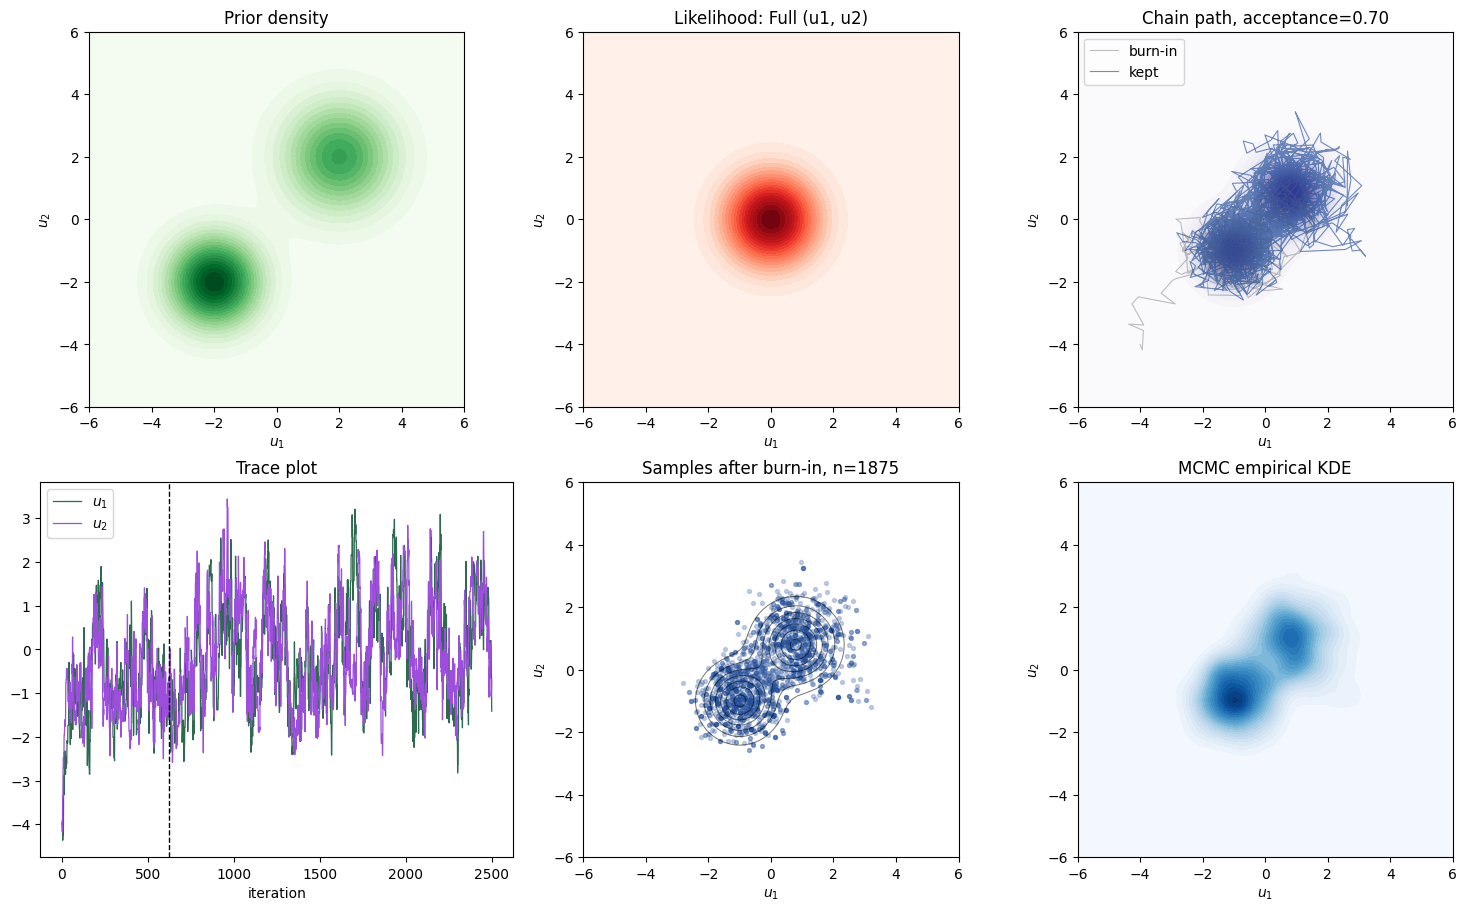

In [1]:
#@title MCMC sampler
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import logsumexp
from scipy.stats import multivariate_normal, norm

DEFAULTS = {
    "n_steps": 2500,
    "burn_in_fraction": 0.25,
    "proposal_scale": 0.55,
    "observation": "Full (u1, u2)",
    "y1": 0.0,
    "y2": 0.0,
    "noise_std": 1.0,
    "seed": 42,
    "grid_size": 80,
    "grid_limit": 6.0,
    "bandwidth": 0.32,
}

use_default = False #@param {type:"boolean"}
n_steps = 2500 #@param {type:"slider", min:500, max:8000, step:250}
burn_in_fraction = 0.25 #@param {type:"slider", min:0.0, max:0.8, step:0.05}
proposal_scale = 0.55 #@param {type:"slider", min:0.05, max:2.5, step:0.05}
observation = "Full (u1, u2)" #@param ["Full (u1, u2)", "U1 only", "U2 only"]
y1 = 0.0 #@param {type:"slider", min:-4.0, max:4.0, step:0.25}
y2 = 0.0 #@param {type:"slider", min:-4.0, max:4.0, step:0.25}
noise_std = 1.0 #@param {type:"slider", min:0.1, max:2.0, step:0.1}

params = DEFAULTS.copy()
if not use_default:
    params.update({
        "n_steps": int(n_steps),
        "burn_in_fraction": float(burn_in_fraction),
        "proposal_scale": float(proposal_scale),
        "observation": observation,
        "y1": float(y1),
        "y2": float(y2),
        "noise_std": float(noise_std),
    })

def log_prior(u):
    u = np.atleast_2d(u)
    lp1 = multivariate_normal.logpdf(u, mean=[-2, -2], cov=np.eye(2))
    lp2 = multivariate_normal.logpdf(u, mean=[2, 2], cov=1.5 * np.eye(2))
    return logsumexp(np.vstack([np.log(0.5) + lp1, np.log(0.5) + lp2]), axis=0)

def prior_pdf(pos):
    p1 = multivariate_normal.pdf(pos, mean=[-2, -2], cov=np.eye(2))
    p2 = multivariate_normal.pdf(pos, mean=[2, 2], cov=1.5 * np.eye(2))
    return 0.5 * p1 + 0.5 * p2

def observation_values(u, mode):
    u = np.asarray(u)
    if mode == "Full (u1, u2)":
        return u
    if mode == "U1 only":
        return u[..., 0:1]
    return u[..., 1:2]

def observed_data(p):
    if p["observation"] == "Full (u1, u2)":
        return np.array([p["y1"], p["y2"]])
    if p["observation"] == "U1 only":
        return np.array([p["y1"]])
    return np.array([p["y2"]])

def log_likelihood(u, y_obs, noise, mode):
    hx = observation_values(np.atleast_2d(u), mode)
    residual = hx - y_obs
    return -0.5 * np.sum((residual / noise) ** 2, axis=-1)

def log_posterior(u, y_obs, noise, mode):
    return log_prior(u) + log_likelihood(u, y_obs, noise, mode)

def likelihood_pdf_on_grid(pos, y_obs, noise, mode):
    if mode == "Full (u1, u2)":
        return multivariate_normal.pdf(pos, mean=y_obs, cov=(noise ** 2) * np.eye(2))
    values = observation_values(pos, mode)[..., 0]
    return norm.pdf(values, loc=y_obs[0], scale=noise)

def kde_density(pos, samples, bandwidth):
    density = np.zeros(pos.shape[:2])
    for sample in samples:
        density += multivariate_normal.pdf(pos, mean=sample, cov=bandwidth ** 2)
    return density / max(len(samples), 1)

rng = np.random.default_rng(params["seed"])
y_obs = observed_data(params)
chain = np.zeros((params["n_steps"], 2))
chain[0] = np.array([-4.0, -4.0])
current_logp = log_posterior(chain[0], y_obs, params["noise_std"], params["observation"])[0]
accepted = 0

for n in range(1, params["n_steps"]):
    proposal = chain[n - 1] + rng.normal(scale=params["proposal_scale"], size=2)
    proposal_logp = log_posterior(proposal, y_obs, params["noise_std"], params["observation"])[0]
    if np.log(rng.uniform()) < proposal_logp - current_logp:
        chain[n] = proposal
        current_logp = proposal_logp
        accepted += 1
    else:
        chain[n] = chain[n - 1]

burn_idx = int(params["burn_in_fraction"] * params["n_steps"])
posterior_samples = chain[burn_idx:]
acceptance_rate = accepted / max(params["n_steps"] - 1, 1)

grid = np.linspace(-params["grid_limit"], params["grid_limit"], params["grid_size"])
U1, U2 = np.meshgrid(grid, grid)
pos = np.dstack((U1, U2))
prior = prior_pdf(pos)
likelihood = likelihood_pdf_on_grid(pos, y_obs, params["noise_std"], params["observation"])
posterior = prior * likelihood
posterior = posterior / np.trapezoid(np.trapezoid(posterior, grid, axis=0), grid)
empirical = kde_density(pos, posterior_samples[:: max(len(posterior_samples) // 1000, 1)], params["bandwidth"])

fig, axes = plt.subplots(2, 3, figsize=(15, 9), constrained_layout=True)

axes[0, 0].contourf(U1, U2, prior, levels=24, cmap="Greens")
axes[0, 0].set_title("Prior density")
axes[0, 1].contourf(U1, U2, likelihood, levels=24, cmap="Reds")
axes[0, 1].set_title(f"Likelihood: {params['observation']}")
axes[0, 2].contourf(U1, U2, posterior, levels=24, cmap="Purples")
axes[0, 2].plot(chain[:burn_idx, 0], chain[:burn_idx, 1], color="gray", lw=0.8, alpha=0.5, label="burn-in")
axes[0, 2].plot(chain[burn_idx:, 0], chain[burn_idx:, 1], color="#234f9b", lw=0.8, alpha=0.65, label="kept")
axes[0, 2].legend(loc="upper left")
axes[0, 2].set_title(f"Chain path, acceptance={acceptance_rate:.2f}")

axes[1, 0].plot(chain[:, 0], color="#2d6a4f", lw=0.9, label="$u_1$")
axes[1, 0].plot(chain[:, 1], color="#9d4edd", lw=0.9, label="$u_2$")
axes[1, 0].axvline(burn_idx, color="black", ls="--", lw=1)
axes[1, 0].set_title("Trace plot")
axes[1, 0].set_xlabel("iteration")
axes[1, 0].legend()

axes[1, 1].scatter(posterior_samples[:, 0], posterior_samples[:, 1], s=8, alpha=0.25, color="#234f9b")
axes[1, 1].contour(U1, U2, posterior, levels=8, colors="black", linewidths=0.7, alpha=0.55)
axes[1, 1].set_title(f"Samples after burn-in, n={len(posterior_samples)}")

axes[1, 2].contourf(U1, U2, empirical, levels=24, cmap="Blues")
axes[1, 2].set_title("MCMC empirical KDE")

for ax in [axes[0, 0], axes[0, 1], axes[0, 2], axes[1, 1], axes[1, 2]]:
    ax.set_xlabel("$u_1$")
    ax.set_ylabel("$u_2$")
    ax.set_xlim(-params["grid_limit"], params["grid_limit"])
    ax.set_ylim(-params["grid_limit"], params["grid_limit"])
    ax.set_aspect("equal")

print(f"Random walk Metropolis: acceptance rate = {acceptance_rate:.2f}, burn-in = {burn_idx} steps.")
plt.show()


## Ensemble Kalman inversion

Ensemble Kalman inversion (EKI) evolves an ensemble $\{u_n^{(j)}\}_{j=1}^N$ using empirical covariances between parameters and predicted observations. For predicted observations $w_n^{(j)} = H u_n^{(j)}$, define
$$
C_n^{uw} = \frac{1}{N-1}\sum_{j=1}^N
(u_n^{(j)}-\bar u_n)(w_n^{(j)}-\bar w_n)^T,
\qquad
C_n^{ww} = \frac{1}{N-1}\sum_{j=1}^N
(w_n^{(j)}-\bar w_n)(w_n^{(j)}-\bar w_n)^T.
$$
The ensemble is updated by
$$
u_{n+1}^{(j)}
= u_n^{(j)} + \Delta t \, C_n^{uw}(C_n^{ww}+\Gamma)^{-1}
\left(y - w_n^{(j)}\right).
$$
This derivative-free update acts like an optimizer rather than an exact posterior sampler. With the displayed defaults, the posterior truth is bimodal, but EKI tends to move the ensemble toward a single consensus near the data. This is the intended failure mode to inspect: the final ensemble can underestimate uncertainty and miss the two-mode posterior structure.

**Parameter exploration.**

- Adjust `n_iterations`. Additional iterations move the ensemble farther toward the data-consistent region and can reduce posterior spread through ensemble collapse.
- Adjust `prior_kind`. The Gaussian prior gives a cleaner linear-Gaussian comparison, while the mixed Gaussian prior shows how EKI can blur or select among modes.
- Adjust `inflation`. Values slightly above one preserve ensemble spread for longer, which can slow consensus and change the final empirical covariance.
- Adjust `step_size`. Larger steps move particles more aggressively, while smaller steps make the flow smoother and more gradual.

**Recommended test combinations.** Keep the other parameters at their displayed defaults and compare the bimodal posterior truth, particle flow, final ensemble KDE, and final spread.

| Exp ID | Prior | Iterations | Step size | Inflation |
| :--- | :--- | :---: | :---: | :---: |
| **1** | Gaussian | 1 | 1.0 | 1.00 |
| **2** | Gaussian | 20 | 0.5 | 1.00 |
| **3** | Mixed Gaussian | 20 | 0.5 | 1.00 |
| **4** | Mixed Gaussian | 50 | 0.5 | 1.00 |
| **5** | Mixed Gaussian | 50 | 0.3 | 1.05 |

**Note.** Standard EKI is not designed to represent multimodal posterior structure. For Kalman-type methods that are designed to preserve multiple modes, see the Gaussian Mixture Kalman Inversion paper at [stuart.caltech.edu/publications/pdf/stuart183.pdf](http://stuart.caltech.edu/publications/pdf/stuart183.pdf), the [arXiv version](https://arxiv.org/abs/2406.17263), and the implementation reference [KI.jl](https://github.com/PKU-CMEGroup/InverseProblems.jl/blob/master/Inversion/KI.jl).


EKI: final ensemble mean = [ 0.00644148 -0.00087452], spread = 0.33.


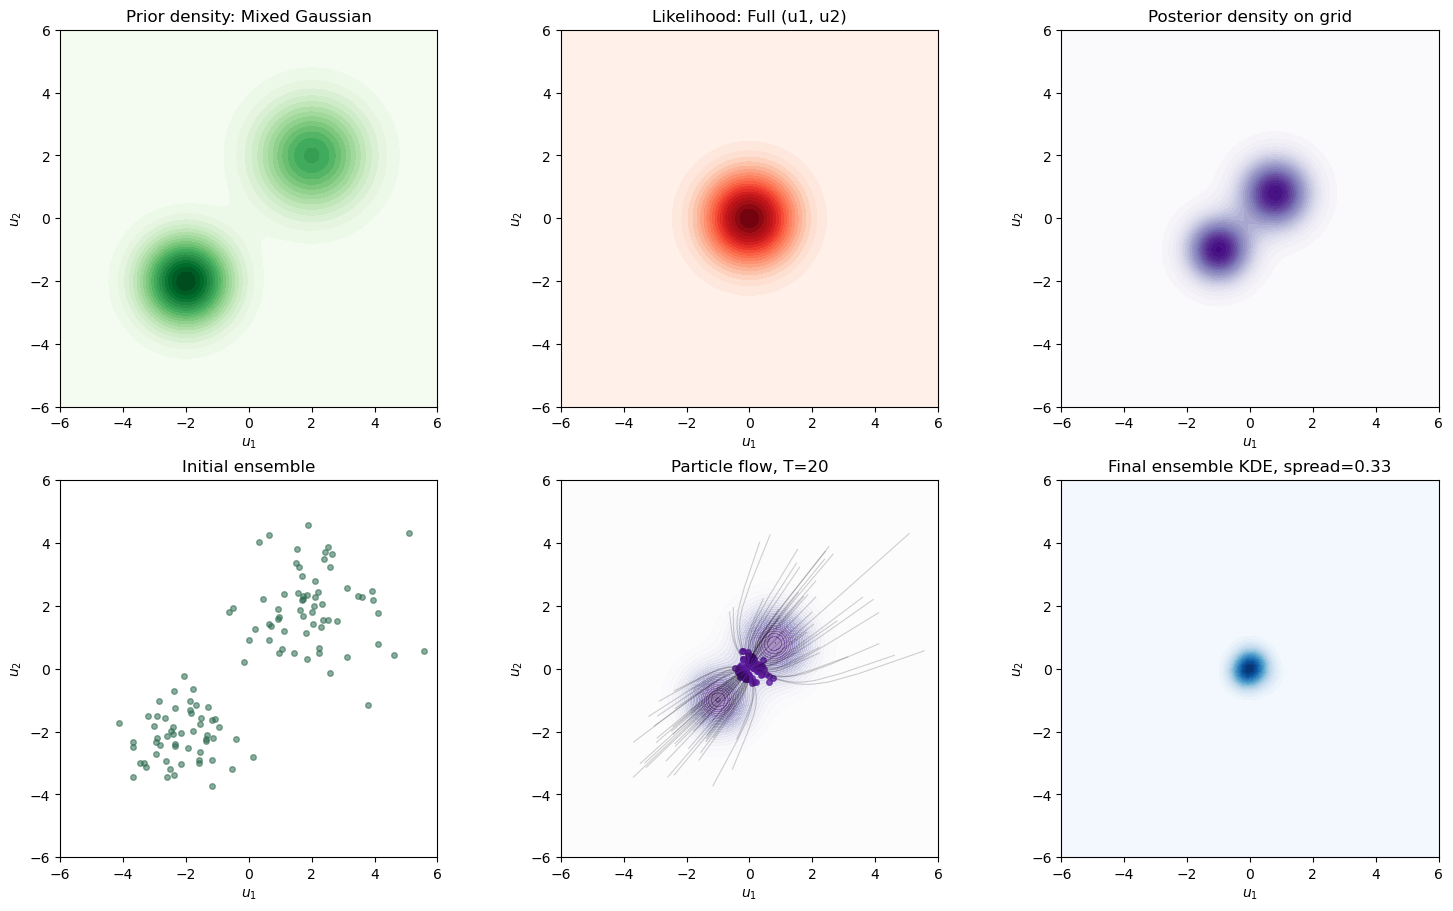

In [ ]:
#@title Ensemble Kalman inversion
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import multivariate_normal, norm

DEFAULTS = {
    "n_ensemble": 120,
    "n_iterations": 20,
    "step_size": 0.5,
    "inflation": 1.0,
    "prior_kind": "Mixed Gaussian",
    "observation": "Full (u1, u2)",
    "y1": 0.0,
    "y2": 0.0,
    "noise_std": 1.0,
    "show_animation": False,
    "seed": 42,
    "grid_size": 80,
    "grid_limit": 6.0,
    "bandwidth": 0.32,
}

use_default = False #@param {type:"boolean"}
n_ensemble = 120 #@param {type:"slider", min:20, max:500, step:20}
n_iterations = 20 #@param {type:"slider", min:1, max:80, step:1}
step_size = 0.5 #@param {type:"slider", min:0.1, max:1.0, step:0.1}
inflation = 1.0 #@param {type:"slider", min:1.0, max:1.1, step:0.01}
prior_kind = "Mixed Gaussian" #@param ["Mixed Gaussian", "Gaussian"]
observation = "Full (u1, u2)" #@param ["Full (u1, u2)", "U1 only", "U2 only"]
y1 = 0.0 #@param {type:"slider", min:-4.0, max:4.0, step:0.25}
y2 = 0.0 #@param {type:"slider", min:-4.0, max:4.0, step:0.25}
noise_std = 1.0 #@param {type:"slider", min:0.1, max:2.0, step:0.1}
show_animation = False #@param {type:"boolean"}

params = DEFAULTS.copy()
if not use_default:
    params.update({
        "n_ensemble": int(n_ensemble),
        "n_iterations": int(n_iterations),
        "step_size": float(step_size),
        "inflation": float(inflation),
        "prior_kind": prior_kind,
        "observation": observation,
        "y1": float(y1),
        "y2": float(y2),
        "noise_std": float(noise_std),
        "show_animation": bool(show_animation),
    })

def prior_pdf(pos, kind):
    if kind == "Gaussian":
        return multivariate_normal.pdf(pos, mean=[0, 0], cov=2.0 * np.eye(2))
    p1 = multivariate_normal.pdf(pos, mean=[-2, -2], cov=np.eye(2))
    p2 = multivariate_normal.pdf(pos, mean=[2, 2], cov=1.5 * np.eye(2))
    return 0.5 * p1 + 0.5 * p2

def sample_prior(n, kind, rng):
    if kind == "Gaussian":
        return rng.multivariate_normal([0, 0], 2.0 * np.eye(2), size=n)
    comp = rng.integers(0, 2, size=n)
    samples = np.zeros((n, 2))
    n0 = np.sum(comp == 0)
    n1 = n - n0
    samples[comp == 0] = rng.multivariate_normal([-2, -2], np.eye(2), size=n0)
    samples[comp == 1] = rng.multivariate_normal([2, 2], 1.5 * np.eye(2), size=n1)
    return samples

def observation_values(u, mode):
    if mode == "Full (u1, u2)":
        return u
    if mode == "U1 only":
        return u[:, 0:1]
    return u[:, 1:2]

def observed_data(p):
    if p["observation"] == "Full (u1, u2)":
        return np.array([p["y1"], p["y2"]])
    if p["observation"] == "U1 only":
        return np.array([p["y1"]])
    return np.array([p["y2"]])

def likelihood_pdf_on_grid(pos, y_obs, noise, mode):
    if mode == "Full (u1, u2)":
        return multivariate_normal.pdf(pos, mean=y_obs, cov=(noise ** 2) * np.eye(2))
    values = pos[..., 0] if mode == "U1 only" else pos[..., 1]
    return norm.pdf(values, loc=y_obs[0], scale=noise)

def kde_density(pos, samples, bandwidth):
    density = np.zeros(pos.shape[:2])
    for sample in samples:
        density += multivariate_normal.pdf(pos, mean=sample, cov=bandwidth ** 2)
    return density / max(len(samples), 1)

rng = np.random.default_rng(params["seed"])
y_obs = observed_data(params)
gamma = (params["noise_std"] ** 2) * np.eye(len(y_obs))
ensemble = sample_prior(params["n_ensemble"], params["prior_kind"], rng)
history = [ensemble.copy()]

for _ in range(params["n_iterations"]):
    mean_u = ensemble.mean(axis=0)
    ensemble = mean_u + params["inflation"] * (ensemble - mean_u)
    predicted = observation_values(ensemble, params["observation"])
    mean_w = predicted.mean(axis=0)
    anomalies_u = ensemble - ensemble.mean(axis=0)
    anomalies_w = predicted - mean_w
    c_uw = anomalies_u.T @ anomalies_w / max(params["n_ensemble"] - 1, 1)
    c_ww = anomalies_w.T @ anomalies_w / max(params["n_ensemble"] - 1, 1)
    gain = c_uw @ np.linalg.inv(c_ww + gamma)
    ensemble = ensemble + params["step_size"] * ((y_obs - predicted) @ gain.T)
    history.append(ensemble.copy())

history = np.array(history)
spread = np.sqrt(np.trace(np.cov(ensemble.T))) if len(ensemble) > 1 else 0.0

grid = np.linspace(-params["grid_limit"], params["grid_limit"], params["grid_size"])
U1, U2 = np.meshgrid(grid, grid)
pos = np.dstack((U1, U2))
prior = prior_pdf(pos, params["prior_kind"])
likelihood = likelihood_pdf_on_grid(pos, y_obs, params["noise_std"], params["observation"])
posterior = prior * likelihood
posterior = posterior / np.trapezoid(np.trapezoid(posterior, grid, axis=0), grid)
final_kde = kde_density(pos, ensemble, params["bandwidth"])

fig, axes = plt.subplots(2, 3, figsize=(15, 9), constrained_layout=True)

axes[0, 0].contourf(U1, U2, prior, levels=24, cmap="Greens")
axes[0, 0].set_title(f"Prior density: {params['prior_kind']}")
axes[0, 1].contourf(U1, U2, likelihood, levels=24, cmap="Reds")
axes[0, 1].set_title(f"Likelihood: {params['observation']}")
axes[0, 2].contourf(U1, U2, posterior, levels=24, cmap="Purples")
axes[0, 2].set_title("Posterior density on grid")

axes[1, 0].scatter(history[0, :, 0], history[0, :, 1], s=16, alpha=0.55, color="#2d6a4f")
axes[1, 0].set_title("Initial ensemble")

axes[1, 1].contourf(U1, U2, posterior, levels=24, cmap="Purples", alpha=0.45)
for j in range(min(params["n_ensemble"], 80)):
    axes[1, 1].plot(history[:, j, 0], history[:, j, 1], color="black", alpha=0.18, lw=0.8)
axes[1, 1].scatter(ensemble[:, 0], ensemble[:, 1], s=16, alpha=0.75, color="#5a189a")
axes[1, 1].set_title(f"Particle flow, T={params['n_iterations']}")

axes[1, 2].contourf(U1, U2, final_kde, levels=24, cmap="Blues")
axes[1, 2].set_title(f"Final ensemble KDE, spread={spread:.2f}")

for ax in axes.flat:
    ax.set_xlabel("$u_1$")
    ax.set_ylabel("$u_2$")
    ax.set_xlim(-params["grid_limit"], params["grid_limit"])
    ax.set_ylim(-params["grid_limit"], params["grid_limit"])
    ax.set_aspect("equal")

print(f"EKI: final ensemble mean = {ensemble.mean(axis=0)}, spread = {spread:.2f}.")
plt.show()

if params["show_animation"]:
    from IPython.display import HTML, display
    from matplotlib.animation import FuncAnimation

    fig_anim, ax_anim = plt.subplots(figsize=(6, 6))
    ax_anim.contourf(U1, U2, posterior, levels=24, cmap="Purples", alpha=0.45)
    points = ax_anim.scatter(history[0, :, 0], history[0, :, 1], s=18, color="#5a189a", alpha=0.75)
    ax_anim.set_xlim(-params["grid_limit"], params["grid_limit"])
    ax_anim.set_ylim(-params["grid_limit"], params["grid_limit"])
    ax_anim.set_aspect("equal")
    ax_anim.set_xlabel("$u_1$")
    ax_anim.set_ylabel("$u_2$")

    def update(frame):
        points.set_offsets(history[frame])
        ax_anim.set_title(f"EKI particle flow, iteration {frame}")
        return (points,)

    anim = FuncAnimation(fig_anim, update, frames=len(history), interval=250, blit=True)
    plt.close(fig_anim)
    display(HTML(anim.to_jshtml()))


## Comparison

The three methods use the same Bayesian inverse problem but answer it in different computational languages.

- Importance sampling produces independent prior particles with posterior weights. It is simple and parallel, but it can suffer from weight collapse when the likelihood is much more concentrated than the prior.
- Random walk Metropolis produces correlated posterior samples without requiring the posterior normalizing constant. Its performance depends strongly on the proposal scale and on how well the chain mixes after burn-in.
- Ensemble Kalman inversion uses ensemble covariances to move particles toward the data. It is derivative-free and parallelizable, but in non-Gaussian settings it should be interpreted as an inversion or optimization method rather than an exact posterior sampler.

The bimodal prior makes the contrast visible: a method that represents posterior uncertainty should preserve multiple plausible regions when the data allow them, while an optimization-oriented ensemble method may move toward one data-fitting consensus.
